# ProfIQ - ML Evaluation

End-to-end offline evaluation for the two ML components that ship with ProfIQ:

1. **Sentiment classifier** - 3-way head-to-head between
   - `VADER` (rule-based, what the app shipped before)
   - `TF-IDF + Logistic Regression` (the new live default)
   - `DistilBERT` fine-tuned (deeper baseline; not deployed by default)
2. **Content-based recommender** - MiniLM sentence embeddings + cosine KNN over per-professor review documents.

All models are evaluated on the same hash-stratified 70/15/15 train/val/test split (see `backend/sentiment/ml/dataset.py`).

## How to run

```bash
# 1. Build the corpus (long; reuses existing scrape):
cd backend && python -m sentiment.ml.build_corpus --target-reviews 50000

# 2. Train the classifiers:
python -m sentiment.ml.train_classifier
python -m sentiment.ml.train_bert --epochs 2

# 3. Build the embeddings:
python manage.py build_prof_embeddings

# 4. Run this notebook end-to-end.
```

Notebook code paths assume the working directory is the repo's `backend/` folder.

In [1]:
import os, sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

# Find the repo root no matter where the notebook is executed from
# (notebooks/ during interactive jupyter, repo root during nbconvert/nbclient).
def _find_repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'backend' / 'manage.py').exists():
            return p
    raise RuntimeError('Could not find repo root containing backend/manage.py')

REPO_ROOT = _find_repo_root()
BACKEND   = REPO_ROOT / 'backend'
DATA      = BACKEND / 'data' / 'ml'
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))
os.chdir(BACKEND)  # so `data/ml/...` paths work

print('Backend root:', BACKEND)
print('Available artifacts:')
for name in ['corpus.parquet', 'sentiment_clf.joblib', 'sentiment_bert',
             'prof_embeddings.npz', 'clf_metrics.json', 'bert_metrics.json']:
    p = DATA / name
    print('  ', name, '->', 'OK' if p.exists() else 'missing')

Backend root: /Users/afnanhaider/Afn377/University/Semester 4/Data Management for Data Science/CS 210 Project/backend
Available artifacts:
   corpus.parquet -> OK
   sentiment_clf.joblib -> OK
   sentiment_bert -> OK
   prof_embeddings.npz -> OK
   clf_metrics.json -> OK
   bert_metrics.json -> OK


## 1. Corpus EDA

What does our training data look like? Class balance is the first thing to check - RMP reviews skew positive, so we expect the negative class to be the rarest.

In [2]:
from sentiment.ml.dataset import split_corpus, load_corpus
from sentiment.ml.labels import LABELS

df = load_corpus(DATA / 'corpus.parquet')
print(f'Total reviews: {len(df):,}')
print(f'Unique professors: {df["professor_id_external"].nunique():,}')
print(f'Unique institutions: {df["institution"].nunique()}')
print(f'Mean review length (chars): {df["text"].str.len().mean():.0f}')
df.head(3)

Total reviews: 49,989
Unique professors: 1,001
Unique institutions: 21
Mean review length (chars): 261


,professor_id_external,professor_name,institution,department,course,text,rating,would_take_again,difficulty,posted_at,source_url,label,bucket
0,rmp:2515691,Eric Eckert,Arizona State University,Computer Science,ACO240,This was the third class I took with Professor...,5.0,1.0,3,2026-04-18 21:14:20 +0000 UTC,https://www.ratemyprofessors.com/professor/251...,positive,val
1,rmp:2515691,Eric Eckert,Arizona State University,Computer Science,ACO350,Professor Eckert gives some of the best lectur...,5.0,1.0,3,2026-04-18 21:04:43 +0000 UTC,https://www.ratemyprofessors.com/professor/251...,positive,test
2,rmp:2515691,Eric Eckert,Arizona State University,Computer Science,ACO350,"A few later assignments may give you trouble, ...",5.0,1.0,4,2026-04-18 07:23:05 +0000 UTC,https://www.ratemyprofessors.com/professor/251...,positive,train


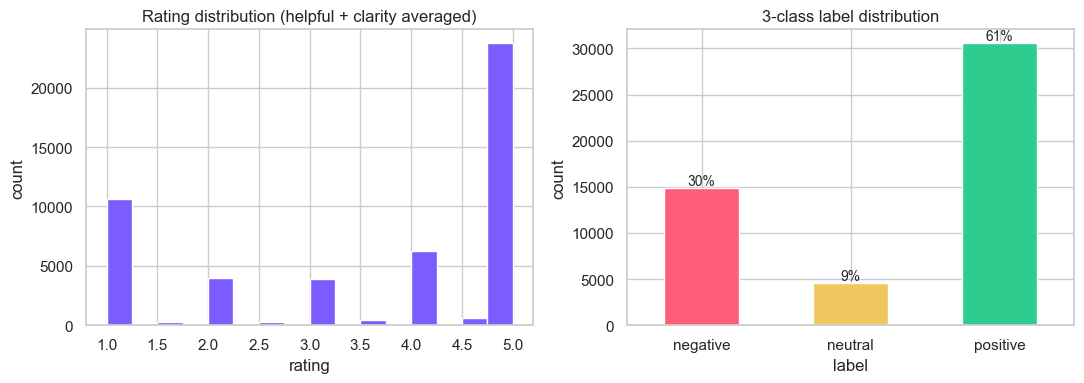

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df['rating'].hist(bins=np.linspace(1, 5, 17), ax=axes[0], color='#7c5cff')
axes[0].set_title('Rating distribution (helpful + clarity averaged)')
axes[0].set_xlabel('rating')
axes[0].set_ylabel('count')

label_counts = df['label'].value_counts().reindex(LABELS, fill_value=0)
label_counts.plot.bar(ax=axes[1], color=['#ff5c7a', '#f0c75e', '#2ecc8f'])
axes[1].set_title('3-class label distribution')
axes[1].set_ylabel('count')
axes[1].set_xticklabels(label_counts.index, rotation=0)
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v, f'{v/len(df):.0%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [4]:
split = split_corpus(DATA / 'corpus.parquet')
print(split.describe())

  train:  35033 | negative=10414 neutral=3272 positive=21347
  val  :   7529 | negative=2270 neutral=676 positive=4583
  test :   7427 | negative=2163 neutral=654 positive=4610


## 2. VADER baseline (rule-based)

Score the test set with the existing rule-based analyzer (academic lexicon overlay + idiom regex layer). This is the bar the learned models need to clear.

In [5]:
from sentiment.analyzer import _adjusted_compound
from sentiment.ml.labels import vader_label
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)

test = split.test
vader_pred = test['text'].apply(lambda t: vader_label(_adjusted_compound(t)))
y_test = test['label'].tolist()

vader_metrics = {
    'accuracy': accuracy_score(y_test, vader_pred),
    'macro_f1': f1_score(y_test, vader_pred, average='macro', labels=list(LABELS)),
    'weighted_f1': f1_score(y_test, vader_pred, average='weighted', labels=list(LABELS)),
}
print('VADER (rule-based):', vader_metrics)
print()
print(classification_report(y_test, vader_pred, labels=list(LABELS), zero_division=0))

VADER (rule-based): {'accuracy': 0.7735290157533324, 'macro_f1': 0.5427684520687808, 'weighted_f1': 0.7470961898521672}

              precision    recall  f1-score   support

    negative       0.77      0.67      0.72      2163
     neutral       0.10      0.03      0.05       654
    positive       0.80      0.93      0.86      4610

    accuracy                           0.77      7427
   macro avg       0.56      0.54      0.54      7427
weighted avg       0.73      0.77      0.75      7427



## 3. TF-IDF + Logistic Regression

The learned model that ships in production. Loaded from the artifact saved by `train_classifier.py`.

In [6]:
import joblib

clf = joblib.load(DATA / 'sentiment_clf.joblib')
logreg_pred = clf.predict(test['text'].tolist())
logreg_metrics = {
    'accuracy': accuracy_score(y_test, logreg_pred),
    'macro_f1': f1_score(y_test, logreg_pred, average='macro', labels=list(LABELS)),
    'weighted_f1': f1_score(y_test, logreg_pred, average='weighted', labels=list(LABELS)),
}
print('TF-IDF + LogReg:', logreg_metrics)
print()
print(classification_report(y_test, logreg_pred, labels=list(LABELS), zero_division=0))

TF-IDF + LogReg: {'accuracy': 0.81607647771644, 'macro_f1': 0.7089731507214574, 'weighted_f1': 0.8335845057297749}

              precision    recall  f1-score   support

    negative       0.85      0.84      0.84      2163
     neutral       0.30      0.55      0.39       654
    positive       0.95      0.84      0.89      4610

    accuracy                           0.82      7427
   macro avg       0.70      0.74      0.71      7427
weighted avg       0.86      0.82      0.83      7427



## 4. DistilBERT fine-tuned

The deep baseline. Skipped automatically if the model directory hasn't been built yet.

In [7]:
bert_pred = None
bert_metrics = None
BERT_DIR = DATA / 'sentiment_bert'
if BERT_DIR.exists():
    from transformers import pipeline
    pipe = pipeline('text-classification', model=str(BERT_DIR),
                    tokenizer=str(BERT_DIR), top_k=None,
                    truncation=True, max_length=256)
    raw = pipe(test['text'].tolist(), batch_size=32)
    bert_pred = []
    for scores in raw:
        scores = scores if isinstance(scores, list) else [scores]
        best = max(scores, key=lambda s: s['score'])
        bert_pred.append(str(best['label']).lower())
    bert_metrics = {
        'accuracy': accuracy_score(y_test, bert_pred),
        'macro_f1': f1_score(y_test, bert_pred, average='macro', labels=list(LABELS)),
        'weighted_f1': f1_score(y_test, bert_pred, average='weighted', labels=list(LABELS)),
    }
    print('DistilBERT:', bert_metrics)
    print()
    print(classification_report(y_test, bert_pred, labels=list(LABELS), zero_division=0))
else:
    print('DistilBERT artifact not built yet - skipping. Run:')
    print('   cd backend && python -m sentiment.ml.train_bert --epochs 2')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT: {'accuracy': 0.8566042816749697, 'macro_f1': 0.636063904853651, 'weighted_f1': 0.8312950935898605}

              precision    recall  f1-score   support

    negative       0.84      0.88      0.86      2163
     neutral       0.32      0.08      0.13       654
    positive       0.88      0.96      0.92      4610

    accuracy                           0.86      7427
   macro avg       0.68      0.64      0.64      7427
weighted avg       0.82      0.86      0.83      7427



## 5. Head-to-head summary

Single comparison table + side-by-side confusion matrices. Reading the matrices: each row is a *true* label, each column is a *predicted* label. Strong diagonal = good model.

In [8]:
summary_rows = [
    ('VADER (rule)',        vader_metrics),
    ('TF-IDF + LogReg',     logreg_metrics),
]
if bert_metrics is not None:
    summary_rows.append(('DistilBERT', bert_metrics))
summary = pd.DataFrame([{'model': n, **m} for n, m in summary_rows])
summary

,model,accuracy,macro_f1,weighted_f1
0,VADER (rule),0.773529,0.542768,0.747096
1,TF-IDF + LogReg,0.816076,0.708973,0.833585
2,DistilBERT,0.856604,0.636064,0.831295


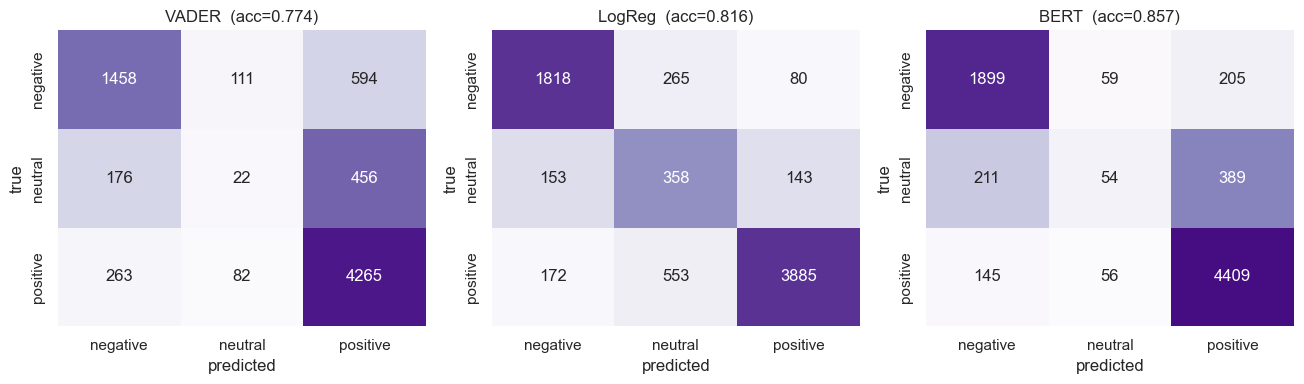

In [9]:
preds_for_cm = [('VADER', vader_pred), ('LogReg', logreg_pred)]
if bert_pred is not None:
    preds_for_cm.append(('BERT', bert_pred))

fig, axes = plt.subplots(1, len(preds_for_cm), figsize=(4.4 * len(preds_for_cm), 4))
if len(preds_for_cm) == 1:
    axes = [axes]
for ax, (name, pred) in zip(axes, preds_for_cm):
    cm = confusion_matrix(y_test, pred, labels=list(LABELS))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Purples',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                cbar=False, vmin=0, vmax=1)
    ax.set_title(f'{name}  (acc={accuracy_score(y_test, pred):.3f})')
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.show()

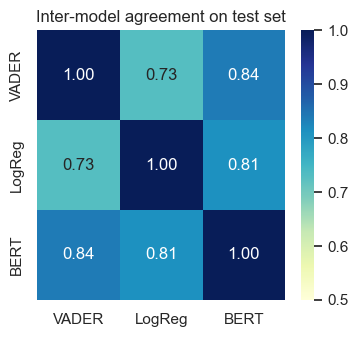

In [10]:
# Inter-model agreement matrix - how often do any two models output the same label?
all_preds = {'VADER': list(vader_pred), 'LogReg': list(logreg_pred)}
if bert_pred is not None:
    all_preds['BERT'] = bert_pred
models = list(all_preds.keys())
agree = np.zeros((len(models), len(models)))
for i, a in enumerate(models):
    for j, b in enumerate(models):
        agree[i, j] = np.mean(np.array(all_preds[a]) == np.array(all_preds[b]))
agree_df = pd.DataFrame(agree, index=models, columns=models)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(agree_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0.5, vmax=1, ax=ax)
ax.set_title('Inter-model agreement on test set')
plt.show()

## 6. Where the models disagree

Sample reviews where the rule-based VADER and the learned LogReg classifier produce different labels. These are the cases where the ML augmentation actually changes a user-visible decision.

In [11]:
disagree = test.copy()
disagree['vader'] = list(vader_pred)
disagree['logreg'] = list(logreg_pred)
disagree = disagree[disagree['vader'] != disagree['logreg']]
print(f'{len(disagree):,} of {len(test):,} test reviews ({len(disagree)/len(test):.1%}) '
      f'show VADER/LogReg disagreement.')
disagree[['rating', 'label', 'vader', 'logreg', 'text']].head(8)

2,005 of 7,427 test reviews (27.0%) show VADER/LogReg disagreement.


,rating,label,vader,logreg,text
3,5.0,positive,neutral,positive,Go to all the classes and extra tutorings.
9,2.0,negative,positive,negative,This professor is rude. He makes fun of studen...
11,5.0,positive,positive,negative,"Professor Odish is really, really good at what..."
14,1.0,negative,positive,negative,took him bc I read all the good reviews here. ...
18,4.0,positive,negative,positive,"He's a great lecturer, but he obviously has Go..."
21,3.0,neutral,positive,negative,I had never made a B in any college class unti...
25,2.0,negative,positive,negative,I would not take any course from him again. Wh...
27,4.0,positive,positive,neutral,Professor Fey assigns *a lot* of readings ever...


## 7. Content-based recommender - MiniLM embeddings

Each professor in the corpus is represented by a single MiniLM document embedding (concatenated reviews, capped at 4k chars). "Similar" professors are nearest neighbors by cosine similarity in that 384-d space.

Intrinsic evaluation: for every prof in the index, compute the top-K neighbors (excluding self) and measure two purity statistics:
- **Department purity@K**: fraction of K neighbors that share the query prof's department.
- **Institution purity@K**: same but for school.

Both should land *meaningfully* above the random-pick baseline. We don't expect 100% - reviews talk about teaching style, which crosses departments - but the lift over chance is what proves the model has learned something.

In [12]:
EMB = DATA / 'prof_embeddings.npz'
META = DATA / 'prof_embeddings_meta.parquet'
if not EMB.exists() or not META.exists():
    print('Embeddings not built yet. Run:')
    print('   cd backend && python manage.py build_prof_embeddings')
    raise SystemExit(0)

data = np.load(EMB, allow_pickle=False)
ids, names, vecs = data['ids'], data['names'], data['vecs'].astype('float32')
meta = pd.read_parquet(META)
meta_by_id = meta.set_index('id')

print(f'Indexed {len(ids):,} professors | embedding dim = {vecs.shape[1]}')
print(f'Top departments in index: {meta["department"].value_counts().head(5).to_dict()}')

Indexed 1,001 professors | embedding dim = 384
Top departments in index: {'Mathematics': 136, 'Psychology': 91, 'Biology': 83, 'English': 59, 'Economics': 58}


In [13]:
K = 5
sim = vecs @ vecs.T
np.fill_diagonal(sim, -1)
top_idx = np.argpartition(-sim, kth=K, axis=1)[:, :K]
row_idx = np.arange(len(ids))[:, None]
order = np.argsort(-sim[row_idx, top_idx], axis=1)
top_idx = top_idx[row_idx, order]

# Force a plain numpy object array - pyarrow-backed pandas extension arrays
# don't support 2-D fancy indexing (`arr[matrix_of_ints]`) which we need below.
depts = np.asarray(meta['department'].fillna('').astype(str).tolist(), dtype=object)
insts = np.asarray(meta['institution'].fillna('').astype(str).tolist(), dtype=object)

dept_purity = (depts[top_idx] == depts[:, None]).mean(axis=1)
inst_purity = (insts[top_idx] == insts[:, None]).mean(axis=1)

from collections import Counter
dept_counts = Counter(depts)
inst_counts = Counter(insts)
n = len(depts)
rand_dept = sum((c / n) ** 2 for c in dept_counts.values())
rand_inst = sum((c / n) ** 2 for c in inst_counts.values())

summary = pd.DataFrame({
    'metric': [f'dept purity@{K}', f'institution purity@{K}'],
    'value':  [dept_purity.mean(), inst_purity.mean()],
    'random_baseline': [rand_dept, rand_inst],
    'lift_x':  [dept_purity.mean() / rand_dept, inst_purity.mean() / rand_inst],
})
summary

,metric,value,random_baseline,lift_x
0,dept purity@5,0.230370,0.055199,4.173473
1,institution purity@5,0.093307,0.049901,1.869831


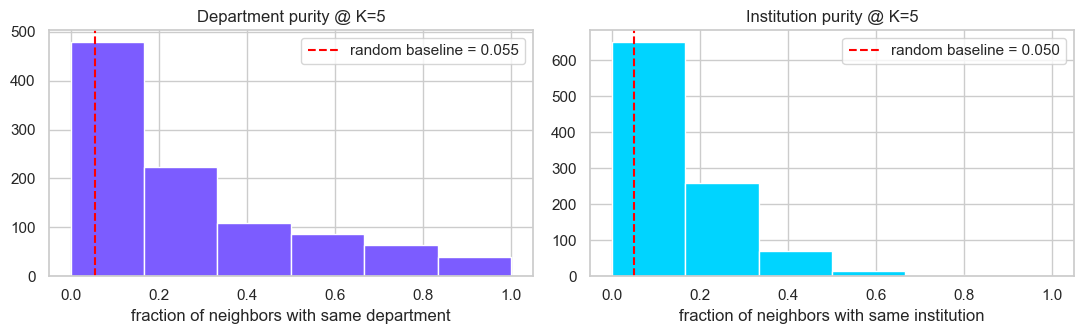

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(dept_purity, bins=np.linspace(0, 1, K + 2),
             color='#7c5cff', edgecolor='white')
axes[0].axvline(rand_dept, color='red', linestyle='--',
                label=f'random baseline = {rand_dept:.3f}')
axes[0].set_title(f'Department purity @ K={K}')
axes[0].set_xlabel('fraction of neighbors with same department')
axes[0].legend()

axes[1].hist(inst_purity, bins=np.linspace(0, 1, K + 2),
             color='#00d4ff', edgecolor='white')
axes[1].axvline(rand_inst, color='red', linestyle='--',
                label=f'random baseline = {rand_inst:.3f}')
axes[1].set_title(f'Institution purity @ K={K}')
axes[1].set_xlabel('fraction of neighbors with same institution')
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Qualitative top-5 - what does the recommender actually retrieve?

Pick a few well-reviewed professors and inspect their nearest neighbors. Good neighbors share teaching-style descriptors ("clear", "strict", "dry but knowledgeable") even when they're from different schools.

In [15]:
samples = meta.sort_values('n_reviews', ascending=False).head(5)
rows = []
for _, q in samples.iterrows():
    qi = np.where(ids == q['id'])[0][0]
    sims_row = vecs @ vecs[qi]
    sims_row[qi] = -1
    top = np.argsort(-sims_row)[:5]
    for rank, ni in enumerate(top, 1):
        nid = ids[ni]
        info = meta_by_id.loc[nid] if nid in meta_by_id.index else None
        rows.append({
            'query_prof':     q['name'],
            'query_inst':     q['institution'],
            'rank':           rank,
            'neighbor':       info['name'] if info is not None else nid,
            'neighbor_inst':  info['institution'] if info is not None else '',
            'neighbor_dept':  info['department']  if info is not None else '',
            'cosine':         round(float(sims_row[ni]), 3),
        })
pd.DataFrame(rows)

,query_prof,query_inst,rank,neighbor,neighbor_inst,neighbor_dept,cosine
0,Daniel O'Connell,Tarrant County College (all),1,John Ackroff,Rutgers - State University of New Jersey,Psychology,0.745
1,Daniel O'Connell,Tarrant County College (all),2,Sean Neiswenter,University of Nevada Las Vegas,Biology,0.723
2,Daniel O'Connell,Tarrant County College (all),3,David Freeman,California State University Fullerton,History,0.721
3,Daniel O'Connell,Tarrant County College (all),4,Steven Francis,San Jose State University,Business,0.719
4,Daniel O'Connell,Tarrant County College (all),5,Craig Burnside,Tarrant County College (all),Biology,0.715
5,Ines Miyares,Hunter College,1,Elena Cainas,Broward College (all campuses),Science,0.754
6,Ines Miyares,Hunter College,2,Randy Rutberg,Hunter College,Geography,0.753
7,Ines Miyares,Hunter College,3,Elizabeth Guzik,California State University Long Beach,English,0.746
8,Ines Miyares,Hunter College,4,Terry Hatkoff,California State University - Northridge,Sociology,0.738
9,Ines Miyares,Hunter College,5,Rebecca Addington,University of Wisconsin - Madison,Psychology,0.731


## 9. Saved metrics (for reference)

Both training scripts dump structured metrics JSONs alongside their model artifacts. Loading them here gives a stable record of what the *training* run produced (the cells above re-evaluate live against whatever artifacts are currently on disk).

In [16]:
for name in ['clf_metrics.json', 'bert_metrics.json']:
    p = DATA / name
    if not p.exists():
        print(f'{name}: not present')
        continue
    print(f'--- {name} ---')
    print(json.dumps(json.loads(p.read_text()), indent=2)[:1200])
    print()

--- clf_metrics.json ---
{
  "model": "tfidf_logreg",
  "fit_seconds": 2.24,
  "n_train": 35033,
  "n_val": 7529,
  "n_test": 7427,
  "val": {
    "accuracy": 0.8039580289547085,
    "macro_f1": 0.691327884182552,
    "weighted_f1": 0.8209915971304586,
    "confusion_matrix": [
      [
        1876,
        303,
        91
      ],
      [
        161,
        330,
        185
      ],
      [
        202,
        534,
        3847
      ]
    ],
    "labels": [
      "negative",
      "neutral",
      "positive"
    ],
    "per_class": {
      "negative": {
        "precision": 0.8378740509155873,
        "recall": 0.826431718061674,
        "f1-score": 0.8321135506764249,
        "support": 2270.0
      },
      "neutral": {
        "precision": 0.2827763496143959,
        "recall": 0.4881656804733728,
        "f1-score": 0.3581117742810635,
        "support": 676.0
      },
      "positive": {
        "precision": 0.9330584525830706,
        "recall": 0.8394065022910757,
        "f1